# PBMC3K end-to-end workflow

This notebook introduces a complete scAtlasPy workflow on the PBMC3K dataset. PBMC3K is small enough to inspect with Scanpy, but here it is used as a compact teaching example for the same on-disk workflow that scAtlasPy applies to much larger atlases.

The central object is an `Atlas`: a persistent `.sasql` database that stores the expression matrix, cell and gene metadata, filtered analysis views, embeddings, cluster labels, marker statistics, and annotation results. The user-facing workflow stays close to familiar single-cell analysis in Python, while the data and intermediate results remain queryable on disk rather than being held entirely in memory.

This tutorial starts from `data/pbmc3k.h5ad`, creates a temporary atlas under `tmp/tutorials/basic_pbmc3k/`, and then runs quality control, preprocessing, PCA, KMeans clustering, UMAP, marker-gene ranking, and manual cell-type annotation.

## Setup

Run this notebook in an environment where scAtlasPy and its documentation dependencies are installed. In this repository, the validated development environment is `scatlaspy-dev`.

The first cell resolves the repository root, locates `data/pbmc3k.h5ad`, and creates a clean temporary `.sasql` database for the tutorial. Re-running the notebook will replace only this tutorial database; it will not modify the source h5ad file.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import scanpy as sc
import scatlaspy as sap

warnings.filterwarnings("ignore", category=FutureWarning)
sap.set_verbosity("warning")

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / "pyproject.toml").exists():
    repo_root = repo_root.parent

data_path = repo_root / "data" / "pbmc3k.h5ad"
work_dir = repo_root / "tmp" / "tutorials" / "basic_pbmc3k"
db_stem = work_dir / "pbmc3k_basic"
db_path = db_stem.with_suffix(".sasql")

work_dir.mkdir(parents=True, exist_ok=True)
if db_path.exists():
    db_path.unlink()

print(f"data: {data_path.relative_to(repo_root)}")
print(f"database: {db_path.relative_to(repo_root)}")

data: data/pbmc3k.h5ad
database: tmp/tutorials/basic_pbmc3k/pbmc3k_basic.sasql


## Inspect the input h5ad file

scAtlasPy can import h5ad files directly. For a small tutorial dataset, it is still useful to inspect the AnnData object first so new users can connect the familiar Scanpy representation to the Atlas representation used below.

After import, cell metadata from `adata.obs` is stored in the Atlas `obs` table, gene metadata from `adata.var` is stored in `var`, and expression values are stored in sparse matrix tables managed by scAtlasPy.

In [2]:
adata = sc.read_h5ad(data_path, backed="r")
print(adata)
print("obs columns:", list(adata.obs.columns))
print("var columns:", list(adata.var.columns))
adata.file.close()

AnnData object with n_obs × n_vars = 2700 × 32738 backed at '/home/hanxu/scAtlaspy-code-analysis/data/pbmc3k.h5ad'
    var: 'gene_ids'
obs columns: []
var columns: ['gene_ids']


## Create an Atlas database

`load_h5ad()` imports the expression matrix and metadata into a DuckDB-backed Atlas database. The database is a normal file with the `.sasql` suffix, so it can be closed, reopened, queried, and used as the persistent record of the analysis.

This example uses `load_type="random"`, matching the randomized block-import path used for larger datasets. For small data where preserving the exact h5ad cell order is important, `load_type="order"` is also available.

In [3]:
atlas = sap.Atlas(db_stem, db_memory_limit="8GB")
atlas.load_h5ad(data_path, load_type="random")
print(atlas.describe())

load_h5ad:   0%|          | 0/6 [00:00<?, ?it/s]

load_h5ad:  33%|███▎      | 2/6 [00:00<00:00, 10.22it/s]

load_h5ad:  67%|██████▋   | 4/6 [00:00<00:00, 10.31it/s]

load_h5ad: 100%|██████████| 6/6 [00:00<00:00, 10.33it/s]

load_h5ad: 100%|██████████| 6/6 [00:00<00:00, 10.30it/s]

file_name       : /home/hanxu/scAtlaspy-code-analysis/tmp/tutorials/basic_pbmc3k/pbmc3k_basic.sasql
db_memory_limit : 8GB
tables          : 4
table names     : X_HyS_data, X_HyS_indptr, obs, var
n_cells         : 2,700
n_genes         : 32,738


## Quality control

The QC functions compute standard per-cell and per-gene summaries inside the Atlas database. `filter_cells()` and `filter_genes()` mark cells and genes that pass the selected thresholds; they do not physically delete rows from the atlas. This makes threshold changes cheap because the original imported data remain available.

The plots below give the same checks a user would perform in an in-memory Scanpy workflow: highly expressed genes, distributions of QC metrics, and relationships among counts, detected genes, and mitochondrial content.

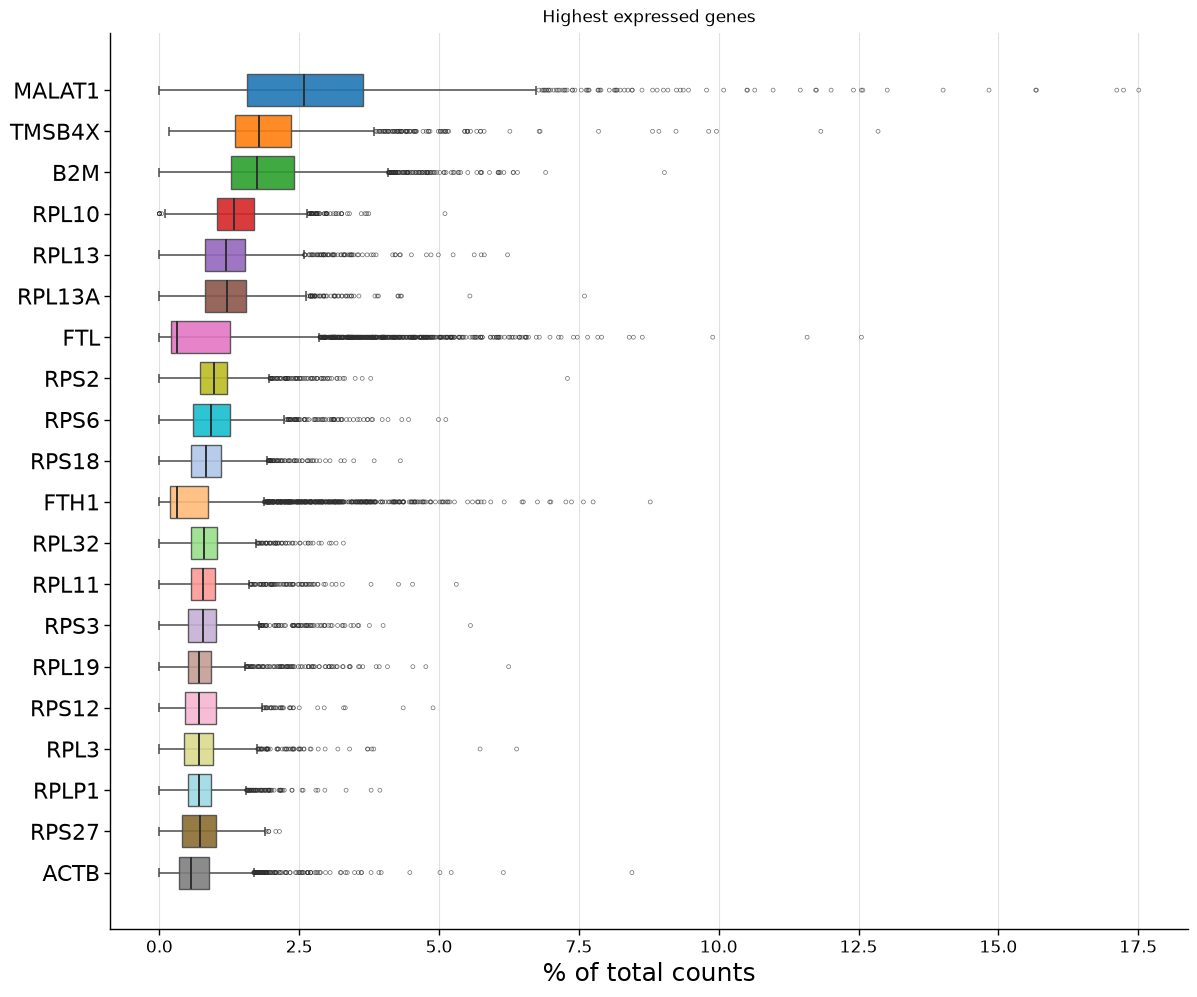

filter_cells:   0%|          | 0/1 [00:00<?, ?chunk/s]

filter_cells: 100%|██████████| 1/1 [00:00<00:00, 121.81chunk/s]

calculate_qc_metrics:   0%|          | 0/1 [00:00<?, ?chunk/s]

calculate_qc_metrics: 100%|██████████| 1/1 [00:00<00:00, 61.34chunk/s]

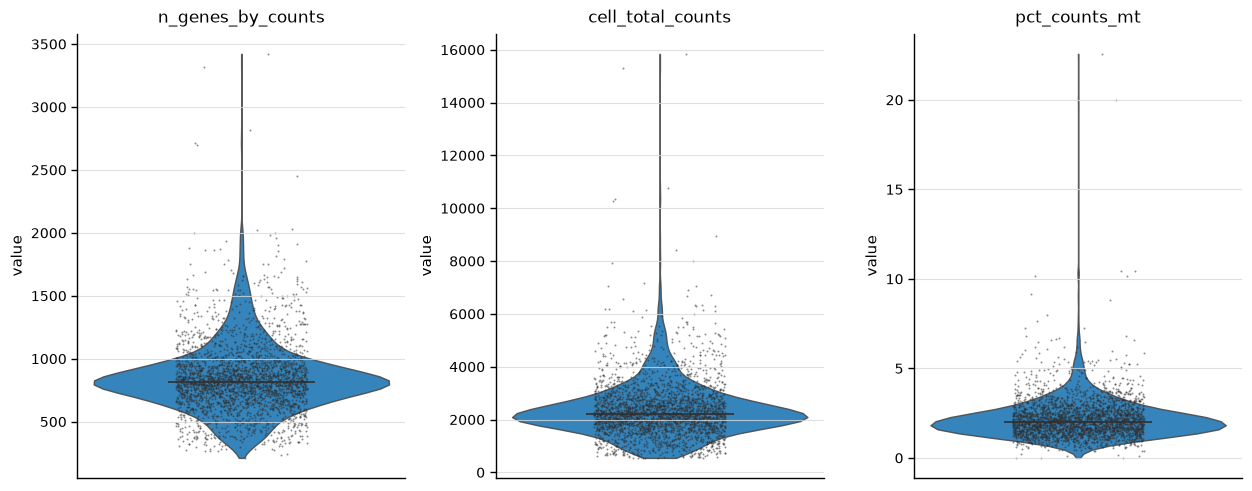

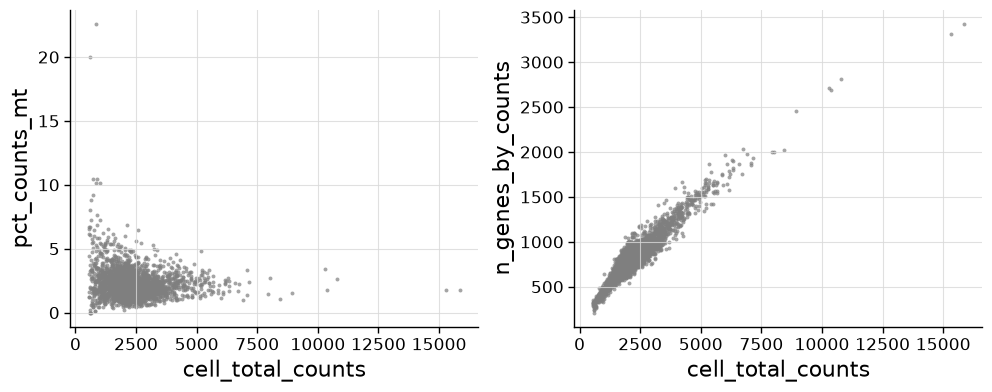

In [4]:
sap.pl.highest_expr_genes(atlas, n_top=20)
plt.show()

sap.pp.filter_cells(atlas, min_genes=200)
sap.pp.filter_genes(atlas, min_cells=3)
sap.pp.calculate_qc_metrics(atlas)

sap.pl.violin_qc_metrics(atlas)
plt.show()

sap.pl.scatter_qc_metrics(atlas)
plt.show()

## Normalize, select highly variable genes, and scale

scAtlasPy stores multiple expression fields side by side in the sparse expression table. In this workflow, raw counts remain in `data`, log-normalized values are written to `data_log1p`, and z-scored values are written to `data_scale`.

`highly_variable_genes()` writes a Boolean marker to the `var` table. The later `build_read_index()` call combines cell filters, gene filters, the HVG flag, and the selected expression field into a compact analysis view for streaming algorithms.

calculate_cell_total_counts:   0%|          | 0/1 [00:00<?, ?chunk/s]

calculate_cell_total_counts: 100%|██████████| 1/1 [00:00<00:00, 93.93chunk/s]

normalize_total_scale_factor:   0%|          | 0/1 [00:00<?, ?chunk/s]

normalize_total_scale_factor: 100%|██████████| 1/1 [00:00<00:00, 117.13chunk/s]

normalize_and_log1p:   0%|          | 0/1 [00:00<?, ?chunk/s]

normalize_and_log1p: 100%|██████████| 1/1 [00:00<00:00, 14.83chunk/s]

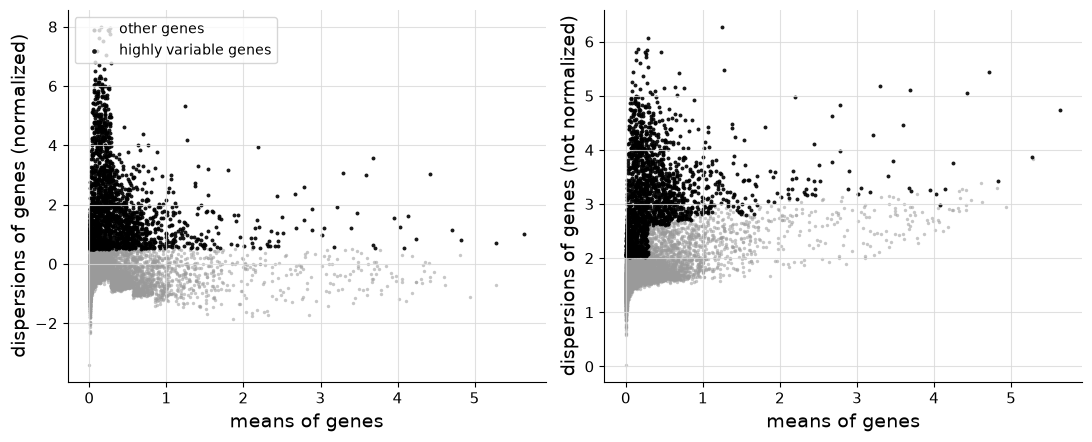

scale:   0%|          | 0/1 [00:00<?, ?chunk/s]

scale: 100%|██████████| 1/1 [00:00<00:00, 12.99chunk/s]

build_read_index:   0%|                                                                             | 0/2286884 [00:00<?, ?rows/s]

build_read_index: 100%|█████████████████████████████████████████████████████████| 2286884/2286884 [00:00<00:00, 41658393.27rows/s]

In [5]:
sap.pp.calculate_cell_total_counts(atlas)
sap.pp.calculate_gene_total_counts(atlas)
sap.pp.normalize_and_log1p(atlas, target_sum=1e4)

sap.pp.highly_variable_genes(atlas, flavor="seurat")
sap.pl.highly_variable_genes(atlas, flavor="seurat")
plt.show()

sap.pp.scale(atlas)
atlas.build_read_index(use_data="data_scale")

## PCA and KMeans

`build_read_index(use_data="data_scale")` has already defined the matrix that downstream algorithms should read. PCA and KMeans then consume this filtered matrix through scAtlasPy minibatch interfaces instead of materializing the complete matrix in memory.

For documentation speed, this notebook uses fewer fitting batches than a production-scale run. On larger atlases, increase `fit_batches` and tune `batch_size` according to the available compute and memory budget.

PCA:   0%|          | 0/60 [00:00<?, ?it/s]

PCA:   2%|▏         | 1/60 [00:00<00:31,  1.85it/s]

PCA:   3%|▎         | 2/60 [00:01<00:33,  1.73it/s]

PCA:   5%|▌         | 3/60 [00:01<00:26,  2.14it/s]

PCA:   7%|▋         | 4/60 [00:02<00:30,  1.84it/s]

...

PCA:  98%|█████████▊| 59/60 [00:30<00:00,  1.82it/s]

PCA: 100%|██████████| 60/60 [00:31<00:00,  2.07it/s]

PCA: 100%|██████████| 60/60 [00:31<00:00,  1.93it/s]

0it [00:00, ?it/s]

2it [00:00, 21.97it/s]

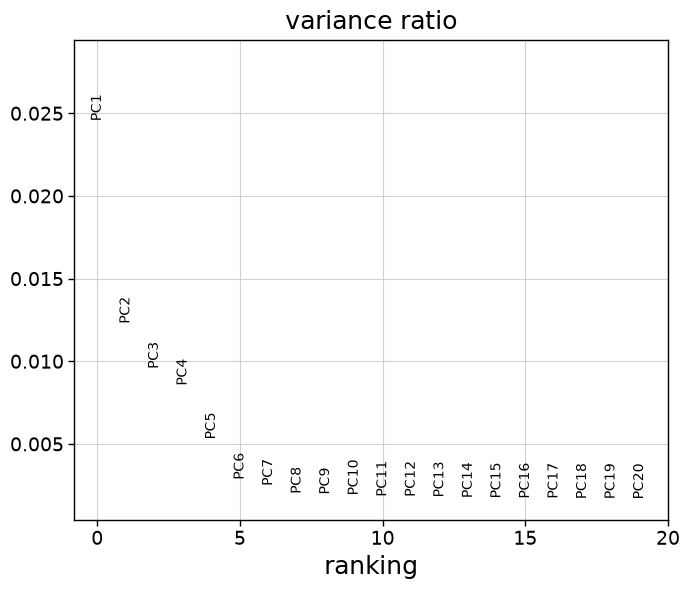

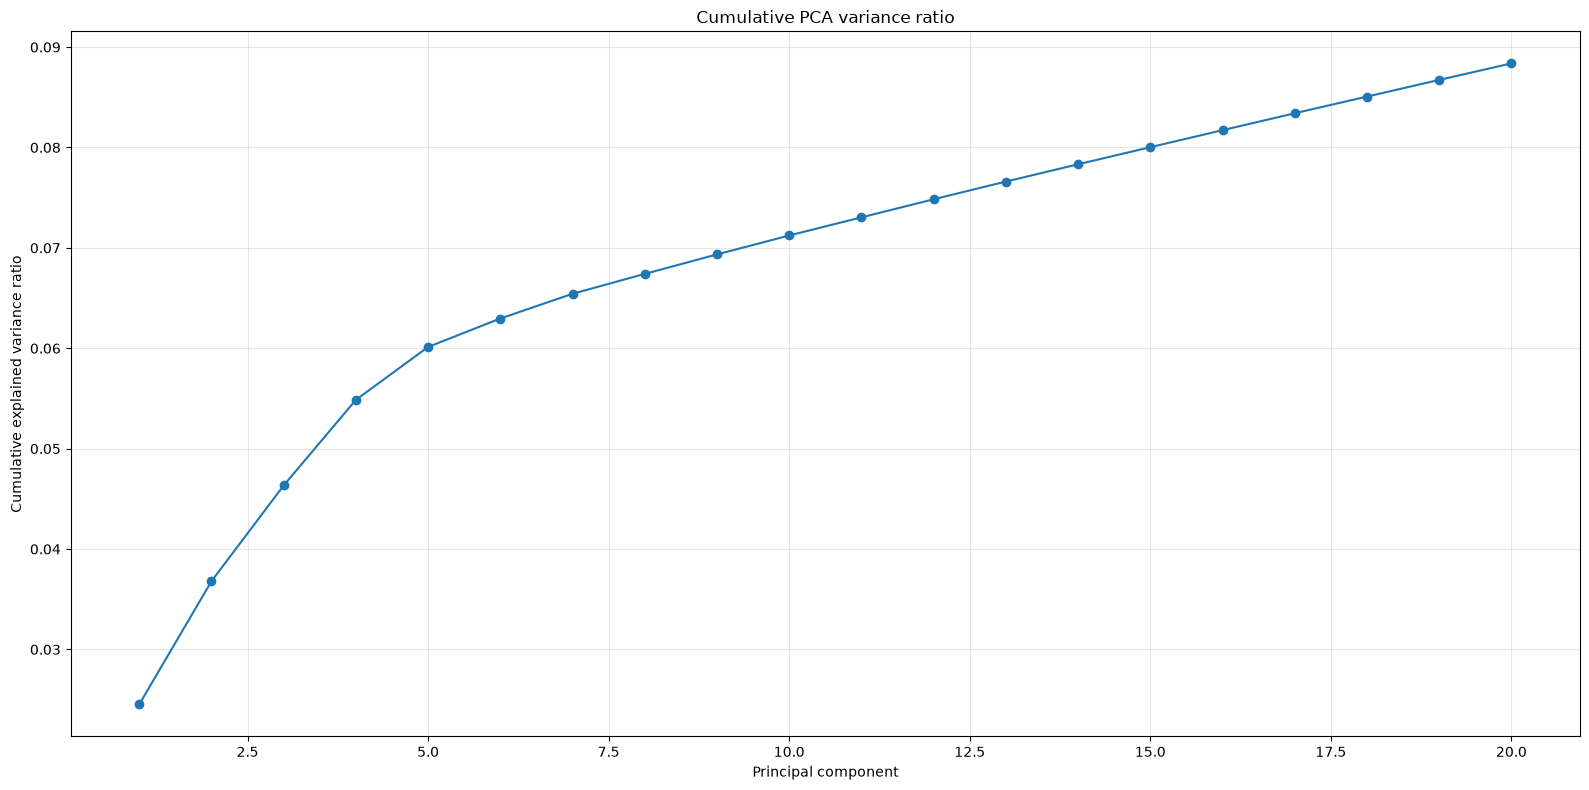

KMeans fit:   0%|          | 0/80 [00:00<?, ?it/s]

KMeans fit:   1%|▏         | 1/80 [00:00<00:18,  4.36it/s]

KMeans fit:   2%|▎         | 2/80 [00:00<00:11,  6.50it/s]

KMeans fit:   4%|▍         | 3/80 [00:00<00:10,  7.50it/s]

KMeans fit:   5%|▌         | 4/80 [00:00<00:11,  6.64it/s]

...

KMeans fit:  96%|█████████▋| 77/80 [00:09<00:00,  9.70it/s]

KMeans fit:  99%|█████████▉| 79/80 [00:09<00:00,  9.66it/s]

KMeans fit: 100%|██████████| 80/80 [00:09<00:00,  8.31it/s]

KMeans predict: 0it [00:00, ?it/s]

KMeans predict: 3it [00:00, 42.03it/s]

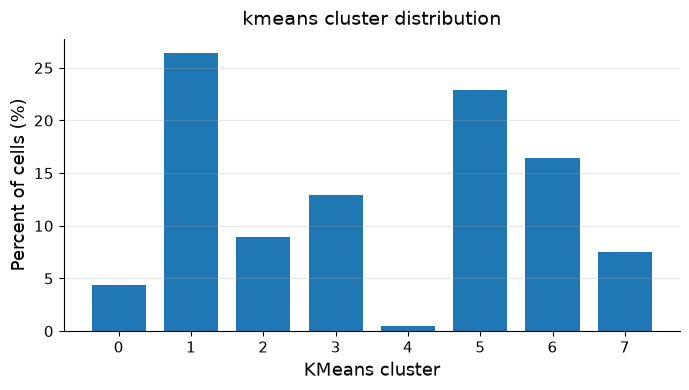

,kmeans,n_cells
0,0,118
1,1,714
2,2,242
3,3,349
4,4,13
5,5,618
6,6,443
7,7,203


In [6]:
sap.tl.pca(atlas, n_components=30, fit_batches=60, batch_size=1024)

sap.pl.pca_variance_ratio(atlas, n_pcs=20)
plt.show()

sap.pl.pca_variance_ratio_cumsum(atlas, n_pcs=20)
plt.show()

sap.tl.kmeans(
    atlas,
    n_components=20,
    n_clusters=8,
    batch_size=1024,
    fit_batches=80,
    use_obs_col="kmeans",
)

sap.pl.kmeans_cluster_size(atlas, use_obs_col="kmeans")
plt.show()

atlas.query("""
    SELECT kmeans, COUNT(*) AS n_cells
    FROM obs
    GROUP BY kmeans
    ORDER BY kmeans
""")

## UMAP and marker expression

UMAP is computed from the PCA coordinates stored in `obsm_X_pca` and written back to the Atlas database as `obsm_X_umap`. Plotting functions read the stored embeddings and can color cells by cluster labels, metadata columns, or gene expression values.

The marker-gene UMAPs show how expression fields can be selected explicitly with `use_data`. Here, `data_log1p` is used for interpretable marker expression.

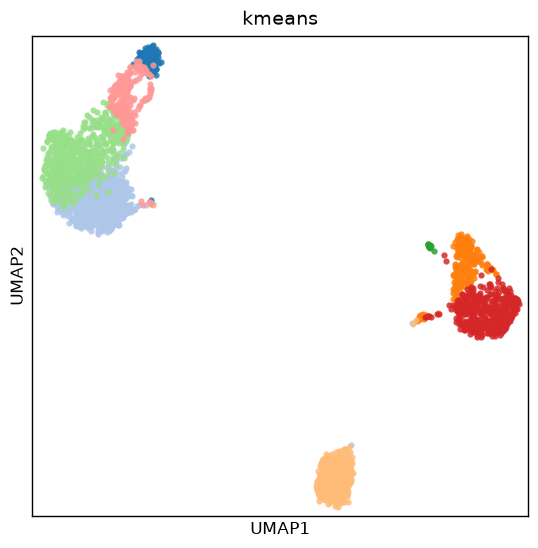

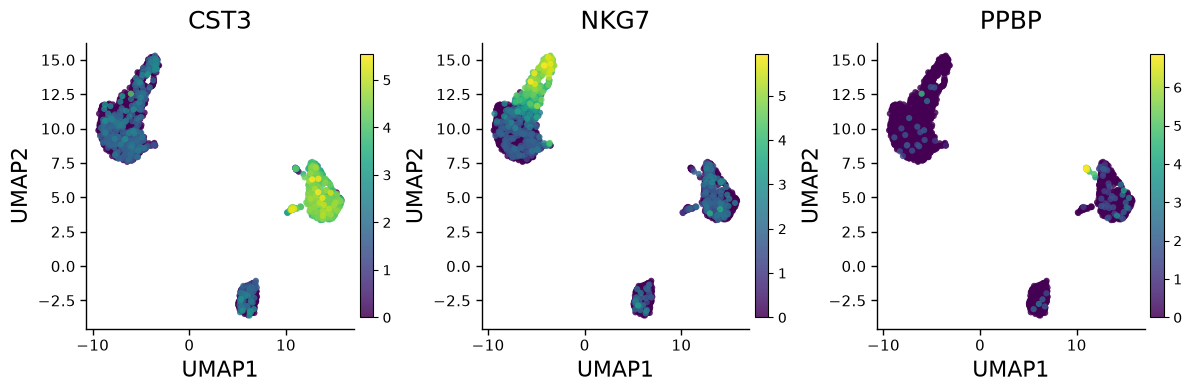

In [7]:
sap.tl.umap(
    atlas,
    fit_sample_n=None,
    n_pcs=20,
    n_neighbors=30,
    min_dist=0.3,
    spread=1.0,
    eval_sample_n=1000,
)

sap.pl.umap(atlas, color="kmeans", sample_n=None, point_size=20, figsize=(8, 6))
plt.show()

sap.pl.umap(
    atlas,
    color=["CST3", "NKG7", "PPBP"],
    use_data="data_log1p",
    sample_n=None,
    point_size=20,
    figsize=(12, 4),
)
plt.show()

## Rank marker genes

`rank_genes_groups()` computes marker statistics for each cluster and stores the result in the Atlas database. The returned table can be inspected directly, plotted with scAtlasPy, or used to support manual annotation.

KMeans labels are an unsupervised grouping, not cell types. Marker ranking provides the evidence needed to interpret those groups biologically.

In [8]:
rank_result = sap.tl.rank_genes_groups(atlas, groupby="kmeans", use_data="data_scale")
rank_result.head(10)

/home/hanxu/scAtlaspy-code-analysis/src/scatlaspy/tools/_rank_genes_groups.py:667: RuntimeWarning: invalid value encountered in log2
  df["logfoldchanges"] = np.log2(
/home/hanxu/scAtlaspy-code-analysis/src/scatlaspy/tools/_rank_genes_groups.py:667: RuntimeWarning: invalid value encountered in log2
  df["logfoldchanges"] = np.log2(
/home/hanxu/scAtlaspy-code-analysis/src/scatlaspy/tools/_rank_genes_groups.py:667: RuntimeWarning: invalid value encountered in log2
  df["logfoldchanges"] = np.log2(
/home/hanxu/scAtlaspy-code-analysis/src/scatlaspy/tools/_rank_genes_groups.py:667: RuntimeWarning: invalid value encountered in log2
  df["logfoldchanges"] = np.log2(
/home/hanxu/scAtlaspy-code-analysis/src/scatlaspy/tools/_rank_genes_groups.py:667: RuntimeWarning: invalid value encountered in log2
  df["logfoldchanges"] = np.log2(
/home/hanxu/scAtlaspy-code-analysis/src/scatlaspy/tools/_rank_genes_groups.py:667: RuntimeWarning: invalid value encountered in log2
  df["logfoldchanges"] = np.log2

,group,reference,rank,atlas_gene_id,names,scores,logfoldchanges,pvals,pvals_adj,mean_in,mean_ref,pct_nz_in,pct_nz_ref,n_in,n_ref,method
0,0,rest,0,31075,NKG7,88.941165,4.921524,1.075531e-173,3.521074e-169,2.486428,0.310106,1.000000,0.270333,118,2582,t-test
1,0,rest,1,22589,GZMB,51.651362,7.459581,2.561641e-86,1.677260e-82,3.440188,0.158313,1.000000,0.080558,118,2582,t-test
2,0,rest,2,4046,GNLY,40.548042,6.561520,1.890078e-73,6.875265e-70,3.122822,0.206896,0.983051,0.142525,118,2582,t-test
3,0,rest,3,17449,PRF1,39.199336,6.524849,1.561469e-71,5.111937e-68,3.128550,0.212842,0.974576,0.121224,118,2582,t-test
4,0,rest,4,23794,B2M,36.478659,NaN,3.208692e-85,1.500660e-81,1.470384,-0.063212,1.000000,0.999613,118,2582,t-test
5,0,rest,5,8889,GZMA,30.281494,4.891957,7.249942e-60,1.695347e-56,2.391753,0.288581,0.957627,0.165763,118,2582,t-test
6,0,rest,6,28832,CST7,29.301991,4.909953,3.839325e-58,8.379456e-55,2.388035,0.284454,0.966102,0.163052,118,2582,t-test
7,0,rest,7,7344,FGFBP2,29.116278,7.130484,2.706600e-56,5.212276e-53,3.222241,0.158616,0.940678,0.071650,118,2582,t-test
8,0,rest,8,19179,CTSW,28.847356,4.060254,4.714133e-58,9.645706e-55,2.080606,0.350772,0.983051,0.268009,118,2582,t-test
9,0,rest,9,2237,FCGR3A,22.450030,4.432063,1.022703e-45,1.521875e-42,2.097392,0.285921,0.915254,0.150658,118,2582,t-test


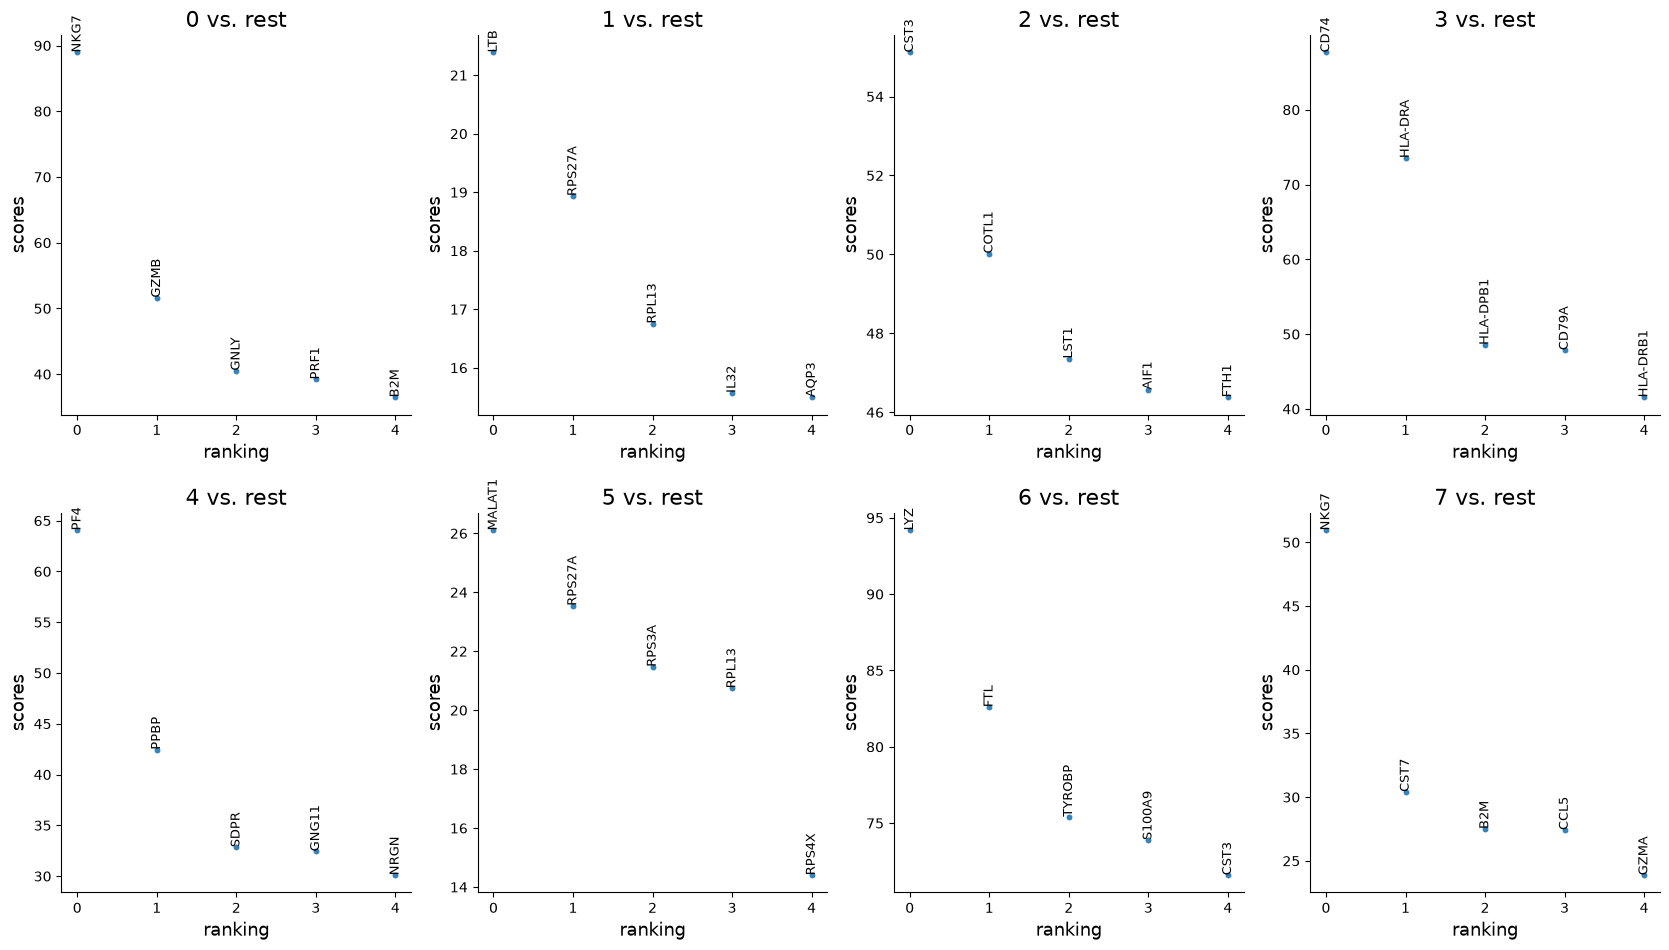

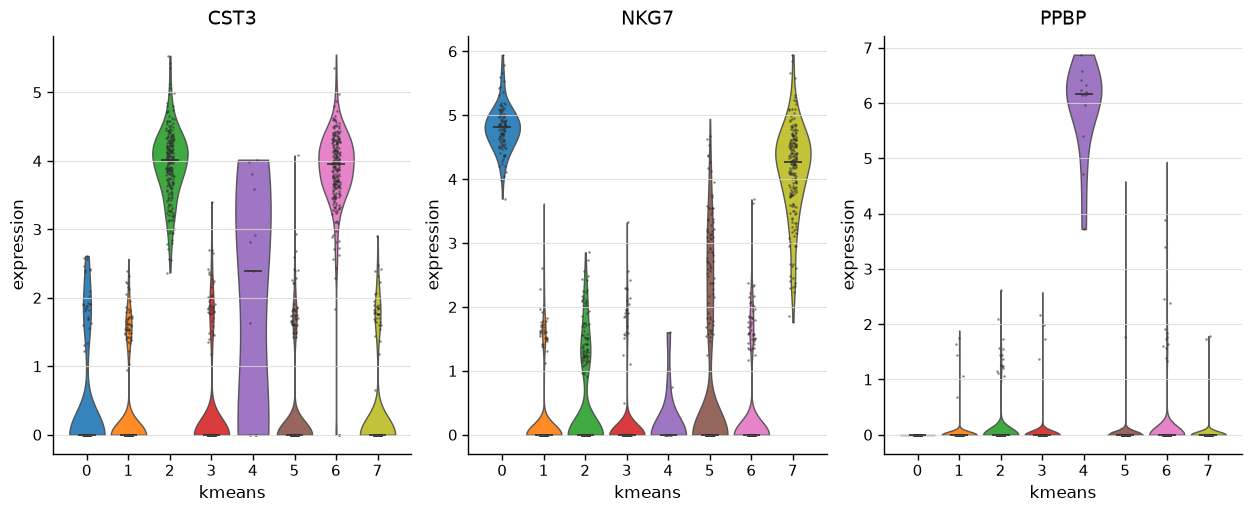

In [9]:
sap.pl.rank_genes_groups(atlas, n_genes=5)
plt.show()

sap.pl.violin(atlas, genes=["CST3", "NKG7", "PPBP"], groupby="kmeans")
plt.show()

## Manual annotation

The mapping below assigns human-readable cell-type labels to KMeans clusters after marker inspection. In a real analysis, this step should be adjusted using the marker-gene rankings, UMAP expression patterns, sample metadata, and domain knowledge.

`manual_annotate_clusters()` writes the labels to a new `obs` column, here `cell_type_manual`, and records the mapping in a separate annotation table so that the interpretation is preserved with the atlas.

In [10]:
mapping = {
    "0": "CD4 T",
    "1": "FCGR3A+ Monocytes",
    "2": "NK",
    "3": "Dendritic",
    "4": "B",
    "5": "CD14+ Monocytes",
    "6": "Megakaryocytes",
    "7": "CD8 T",
}

summary = sap.tl.manual_annotate_clusters(
    atlas,
    cluster_to_cell_type=mapping,
    groupby="kmeans",
    obs_col="cell_type_manual",
    table_name="manual_cluster_annotation",
)
summary

,cluster_id,cell_type,n_cells
0,0,CD4 T,118
1,1,FCGR3A+ Monocytes,714
2,2,NK,242
3,3,Dendritic,349
4,4,B,13
5,5,CD14+ Monocytes,618
6,6,Megakaryocytes,443
7,7,CD8 T,203


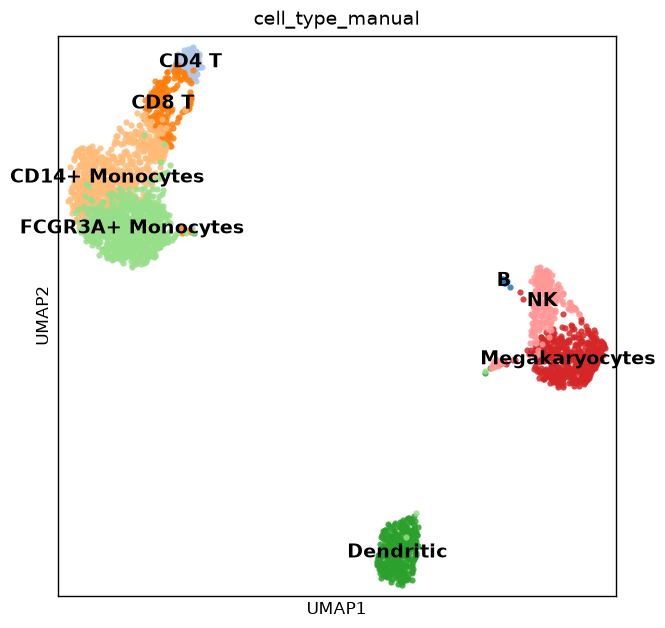

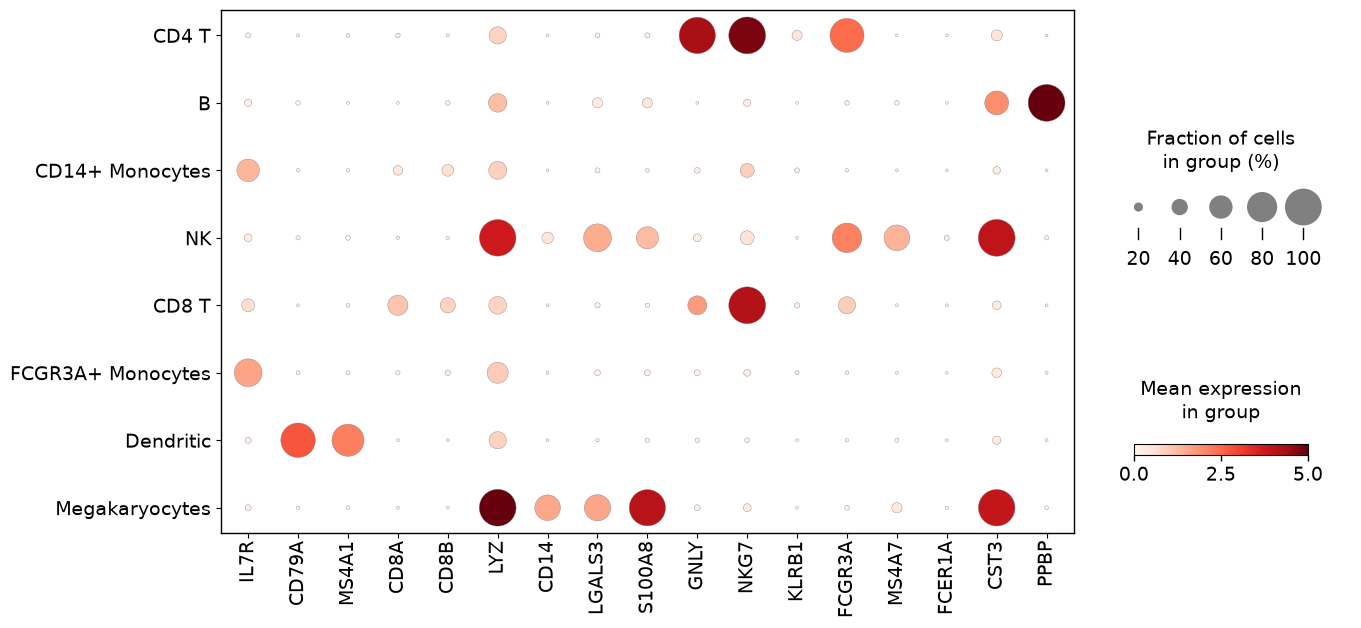

,group_label,gene,mean_expr,pct_expr,n
0,CD4 T,IL7R,0.176588,9.322034,118
1,CD4 T,CD79A,0.042748,2.542373,118
2,CD4 T,MS4A1,0.085312,5.084746,118
3,CD4 T,CD8A,0.142918,7.627119,118
4,CD4 T,CD8B,0.043653,2.542373,118


In [11]:
sap.pl.umap(
    atlas,
    color="cell_type_manual",
    legend_loc="on_data",
    sample_n=None,
    point_size=20,
    figsize=(9, 7),
)
plt.show()

marker_genes = [
    "IL7R", "CD79A", "MS4A1", "CD8A", "CD8B", "LYZ", "CD14",
    "LGALS3", "S100A8", "GNLY", "NKG7", "KLRB1",
    "FCGR3A", "MS4A7", "FCER1A", "CST3", "PPBP",
]

cell_type_order = [
    "CD4 T",
    "B",
    "CD14+ Monocytes",
    "NK",
    "CD8 T",
    "FCGR3A+ Monocytes",
    "Dendritic",
    "Megakaryocytes",
]

dotplot_stats = sap.pl.dotplot(
    atlas,
    genes=marker_genes,
    groupby="cell_type_manual",
    use_data="data_log1p",
    sample_n_per_group=None,
    order=cell_type_order,
)
plt.show()

dotplot_stats.head()

## Close the database

Close the Atlas connection when the workflow is complete. The `.sasql` file remains on disk and can be reopened later for additional analysis, SQL queries, export to AnnData, or method development.

In [12]:
print(atlas.describe())
atlas.close()

file_name       : /home/hanxu/scAtlaspy-code-analysis/tmp/tutorials/basic_pbmc3k/pbmc3k_basic.sasql
db_memory_limit : 8GB
tables          : 18
table names     : X_HyS_data, X_HyS_data_filtered, X_HyS_indptr, X_HyS_indptr_filtered, __append_df, atlas_read_index_meta, kmeans_centers, manual_cluster_annotation, obs, obs_cluster, obsm_X_pca, obsm_X_umap, rank_genes_groups, uns_pca_stats, uns_umap_eval, uns_umap_params, var, varm_PCs
n_cells         : 2,700
n_genes         : 32,738
